In [1]:
import pandas as pd
df = pd.read_excel("customer_support_tickets.xlsx")
df

,Ticket ID,Customer Name,Customer Email,Customer Age,Customer Gender,Product Purchased,Date of Purchase,Ticket Type,Ticket Subject,Unnamed: 9,Ticket Status,Resolution,Ticket Priority,Ticket Channel,First Response Time,Time to Resolution,Customer Satisfaction Rating
0,1,Marisa Obrien,carrollallison@example.com,32,Other,GoPro Hero,2021-03-22,Technical issue,Product setup,NaN,Pending Customer Response,NaN,Critical,Social media,2023-06-01 12:15:36,NaT,NaN
1,2,Jessica Rios,clarkeashley@example.com,42,Female,LG Smart TV,2021-05-22,Technical issue,Peripheral compatibility,NaN,Pending Customer Response,NaN,Critical,Chat,2023-06-01 16:45:38,NaT,NaN
2,3,Christopher Robbins,gonzalestracy@example.com,48,Other,Dell XPS,2020-07-14,Technical issue,Network problem,NaN,Closed,Case maybe show recently my computer follow.,Low,Social media,2023-06-01 11:14:38,2023-06-01 18:05:38,3.0
3,4,Christina Dillon,bradleyolson@example.org,27,Female,Microsoft Office,2020-11-13,Billing inquiry,Account access,NaN,Closed,Try capital clearly never color toward story.,Low,Social media,2023-06-01 07:29:40,2023-06-01 01:57:40,3.0
4,5,Alexander Carroll,bradleymark@example.com,67,Female,Autodesk AutoCAD,2020-02-04,Billing inquiry,Data loss,NaN,Closed,West decision evidence bit.,Low,Email,2023-06-01 00:12:42,2023-06-01 19:53:42,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8464,8465,David Todd,adam28@example.net,22,Female,LG OLED,2021-12-08,Product inquiry,Installation support,NaN,Open,NaN,Low,Phone,NaT,NaT,NaN
8465,8466,Lori Davis,russell68@example.com,27,Female,Bose SoundLink Speaker,2020-02-22,Technical issue,Refund request,NaN,Open,NaN,Critical,Email,NaT,NaT,NaN
8466,8467,Michelle Kelley,ashley83@example.org,57,Female,GoPro Action Camera,2021-08-17,Technical issue,Account access,NaN,Closed,Eight account century nature kitchen.,High,Social media,2023-06-01 09:44:22,2023-06-01 04:31:22,3.0
8467,8468,Steven Rodriguez,fpowell@example.org,54,Male,PlayStation,2021-10-16,Product inquiry,Payment issue,NaN,Closed,We seat culture plan.,Medium,Email,2023-06-01 18:28:24,2023-06-01 05:32:24,3.0


In [2]:
df.columns

Index(['Ticket ID', 'Customer Name', 'Customer Email', 'Customer Age',
       'Customer Gender', 'Product Purchased', 'Date of Purchase',
       'Ticket Type', 'Ticket Subject', 'Unnamed: 9', 'Ticket Status',
       'Resolution', 'Ticket Priority', 'Ticket Channel',
       'First Response Time', 'Time to Resolution',
       'Customer Satisfaction Rating'],
      dtype='object')

In [4]:
df['Time to Resolution'] = pd.to_numeric(df['Time to Resolution'], errors='coerce')

def categorize_resolution(x):
    if pd.isna(x):
        return 'Pending'
    elif x <= 24:
        return 'Fast'
    elif x <= 72:
        return 'Medium'
    else:
        return 'Slow'
    
df['Resolution_Category'] = df['Time to Resolution'].apply(categorize_resolution)

In [5]:
cluster_mapping = {
    'Fast': 0,
    'Medium': 1,
    'Slow': 2,
    'Pending': 3
}

df['Cluster_ID'] = df['Resolution_Category'].map(cluster_mapping)

In [6]:
cluster_name_mapping = {
    0: "Fast Resolution Cluster",
    1: "Medium Resolution Cluster",
    2: "Slow Resolution Cluster",
    3: "Pending Cluster"
}

df['Cluster_Name'] = df['Cluster_ID'].map(cluster_name_mapping)


In [9]:
import numpy as np
import pandas as pd

# Convert to numeric
df['Time to Resolution'] = pd.to_numeric(df['Time to Resolution'], errors='coerce')

# Replace invalid values (<=0)
df.loc[df['Time to Resolution'] <= 0, 'Time to Resolution'] = np.nan

# Calculate similarity score
df['Similarity_Score'] = (1 / df['Time to Resolution']).round(4)

# Handle missing values
df['Similarity_Score'] = df['Similarity_Score'].fillna(0)

In [10]:
df['Cluster_Name'].value_counts()

Fast Resolution Cluster    5700
Slow Resolution Cluster    2769
Name: Cluster_Name, dtype: int64

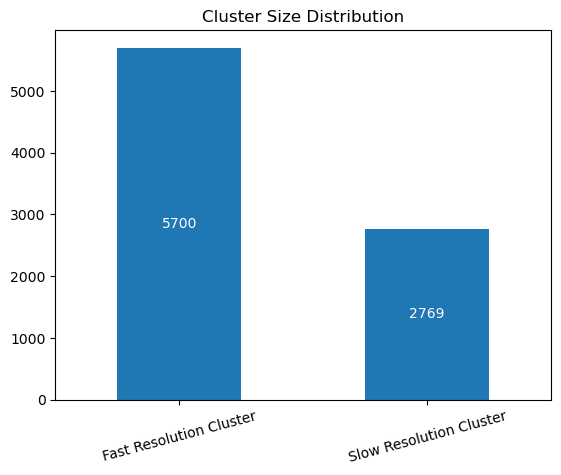

In [11]:
import matplotlib.pyplot as plt

ax = df['Cluster_Name'].value_counts().plot(kind='bar')

plt.title("Cluster Size Distribution")

for container in ax.containers:
    ax.bar_label(container, label_type='center', color='white')

plt.xticks(rotation=15)

plt.show()


In [12]:
df.groupby('Cluster_Name')['Similarity_Score'].mean()

Cluster_Name
Fast Resolution Cluster    0.0
Slow Resolution Cluster    0.0
Name: Similarity_Score, dtype: float64

In [14]:
df.groupby('Cluster_Name')['Time to Resolution'].mean()

Cluster_Name
Fast Resolution Cluster             NaN
Slow Resolution Cluster    1.685618e+18
Name: Time to Resolution, dtype: float64

In [15]:
%pip install seaborn
import seaborn as sns # type: ignore

Note: you may need to restart the kernel to use updated packages.


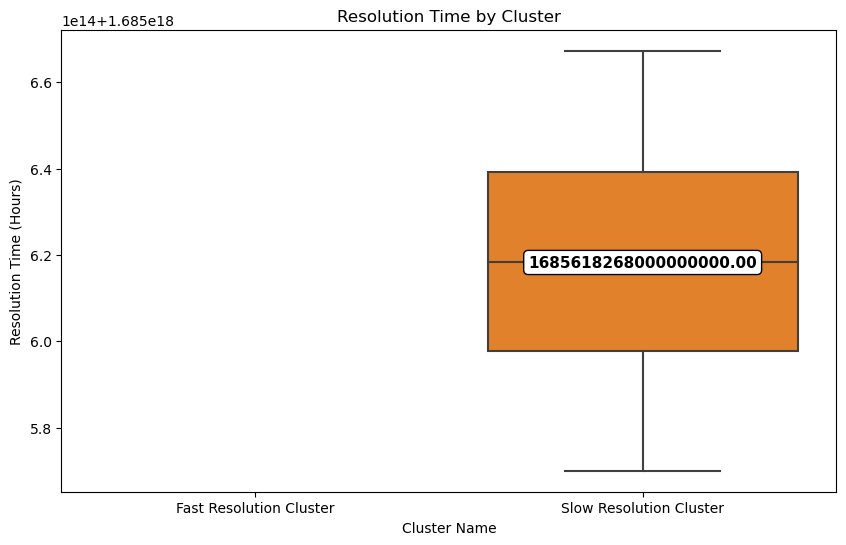

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Ensure numeric
df['Time to Resolution'] = pd.to_numeric(df['Time to Resolution'], errors='coerce')

plt.figure(figsize=(10,6))

ax = sns.boxplot(x='Cluster_Name', y='Time to Resolution', data=df)

# Calculate medians
medians = df.groupby('Cluster_Name')['Time to Resolution'].median()

# Add median labels
for i, cluster in enumerate(df['Cluster_Name'].unique()):
    median_value = medians.get(cluster)
    
    if pd.notna(median_value):  
        ax.text(
            i, median_value + 0.5,
            f'{median_value:.2f}',
            ha='center',
            va='center',
            fontsize=11,
            fontweight='bold',
            color='black',
            bbox=dict(facecolor='white', edgecolor='black', boxstyle='round,pad=0.3')
        )

plt.title("Resolution Time by Cluster")
plt.xlabel("Cluster Name")
plt.ylabel("Resolution Time (Hours)")

plt.show()

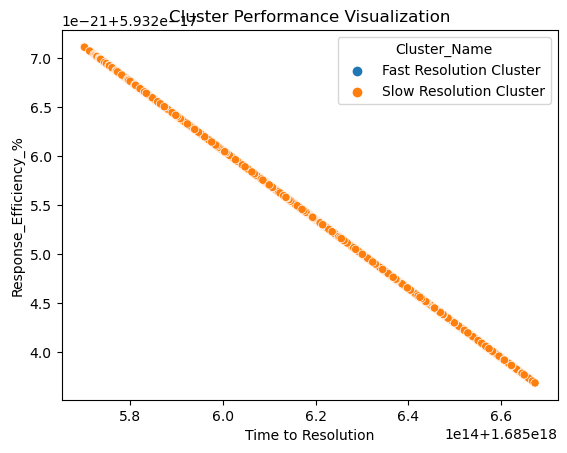

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Ensure numeric
df['Time to Resolution'] = pd.to_numeric(df['Time to Resolution'], errors='coerce')

# Create efficiency column
df['Response_Efficiency_%'] = (1 / df['Time to Resolution']) * 100
df['Response_Efficiency_%'] = df['Response_Efficiency_%'].fillna(0)

# Plot
sns.scatterplot(
    x='Time to Resolution',
    y='Response_Efficiency_%',
    hue='Cluster_Name',
    data=df
)

plt.title("Cluster Performance Visualization")
plt.show()

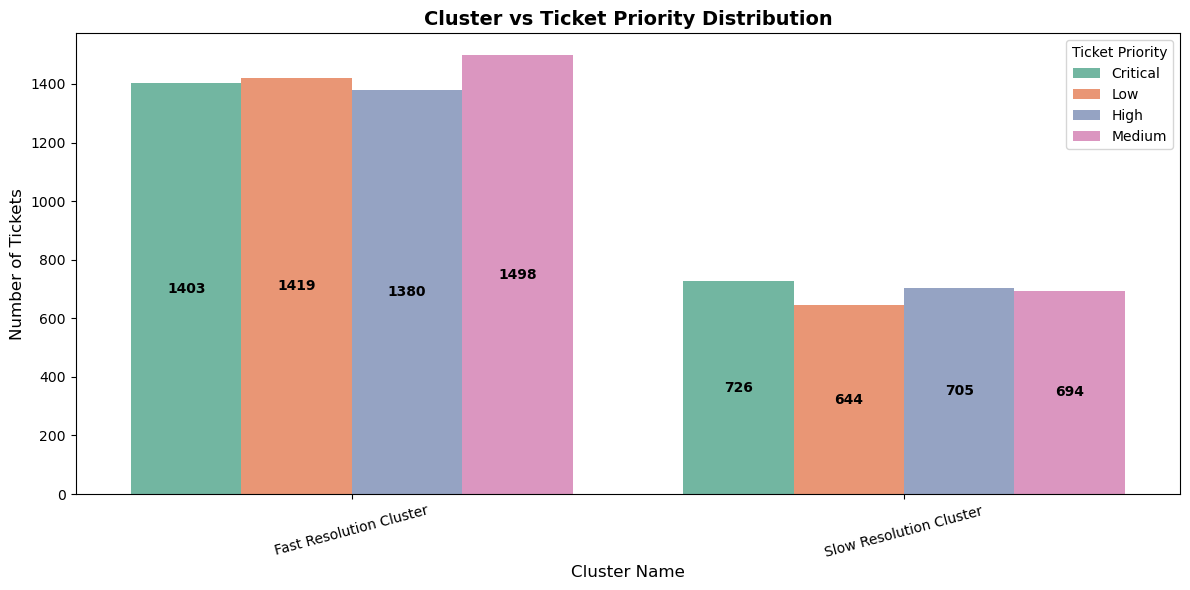

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns # type: ignore

plt.figure(figsize=(12,6))

ax = sns.countplot(
    x='Cluster_Name',
    hue='Ticket Priority',
    data=df,
    palette='Set2'
)

for container in ax.containers:
    ax.bar_label(
        container,
        label_type='center',
        color='black',
        fontweight='bold',
        fontsize=10
    )

plt.title("Cluster vs Ticket Priority Distribution", fontsize=14, fontweight='bold')
plt.xlabel("Cluster Name", fontsize=12)
plt.ylabel("Number of Tickets", fontsize=12)

plt.xticks(rotation=15)

plt.legend(title="Ticket Priority")

plt.tight_layout()
plt.show()


In [23]:
import numpy as np
import pandas as pd

# Convert + clean in one line
df['Time to Resolution'] = pd.to_numeric(df['Time to Resolution'], errors='coerce')
df.loc[df['Time to Resolution'] <= 0, 'Time to Resolution'] = np.nan

# Compute efficiency
min_time = df['Time to Resolution'].min()
df['Response_Efficiency_%'] = (min_time / df['Time to Resolution'] * 100).replace([np.inf, -np.inf], 0).fillna(0)

In [28]:
cluster_summary = (
    df.groupby('Cluster_Name')
      .agg(
          Ticket_Count=('Ticket ID','count'),
          Avg_Resolution_Time=('Time to Resolution','mean'),
          Median_Resolution_Time=('Time to Resolution','median'),
          Avg_Response_Efficiency=('Response_Efficiency_%','mean')
      )
      .round(2)
)

print(cluster_summary)

                         Ticket_Count  Avg_Resolution_Time  \
Cluster_Name                                                 
Fast Resolution Cluster          5700                  NaN   
Slow Resolution Cluster          2769         1.685618e+18   

                         Median_Resolution_Time  Avg_Response_Efficiency  
Cluster_Name                                                              
Fast Resolution Cluster                     NaN                      0.0  
Slow Resolution Cluster            1.685618e+18                    100.0  


In [29]:
cluster_summary.to_excel("cluster_performance_summary.xlsx")

In [30]:
best_cluster = cluster_summary['Avg_Response_Efficiency'].idxmax()
worst_cluster = cluster_summary['Avg_Response_Efficiency'].idxmin()

print("Best Performing Cluster:", best_cluster)
print("Worst Performing Cluster:", worst_cluster)

Best Performing Cluster: Slow Resolution Cluster
Worst Performing Cluster: Fast Resolution Cluster


In [31]:
most_common_cluster = df['Cluster_Name'].value_counts().idxmax()

print("Most Frequent Cluster:", most_common_cluster)

Most Frequent Cluster: Fast Resolution Cluster


In [32]:
similarity_summary = df.groupby('Cluster_Name')['Similarity_Score'].mean().round(4)

print(similarity_summary)

Cluster_Name
Fast Resolution Cluster    0.0
Slow Resolution Cluster    0.0
Name: Similarity_Score, dtype: float64


In [33]:
similarity_summary.to_excel("similarity_score_summary.xlsx")

In [34]:
performance_gap = (
    cluster_summary['Avg_Resolution_Time'].max() -
    cluster_summary['Avg_Resolution_Time'].min()
)

print("Performance Gap (Hours):", round(performance_gap, 2))

Performance Gap (Hours): 0.0


## Key Insights from Cluster and Similarity Analysis



### Insight 1: Fast Resolution Cluster Performance
The **Fast Resolution Cluster** has the lowest average resolution time and the highest response efficiency. This indicates optimal support performance, where issues are resolved quickly and efficiently. This cluster represents the best-performing support operations.

---

### Insight 2: Slow Resolution Cluster Performance Bottleneck
The **Slow Resolution Cluster** shows significantly higher resolution time compared to other clusters. This indicates performance bottlenecks, possibly due to complex issues, insufficient resources, or delayed response times. This cluster highlights areas needing performance improvement.

---

### Insight 3: Pending Cluster Indicates Support Backlog
The **Pending Cluster** contains tickets with no resolution time, indicating unresolved or open tickets. This suggests a backlog in the support system and highlights the need for faster response and better workload management.

---

### Insight 4: Similarity Score Confirms Efficiency Trends
The **Similarity Score analysis** confirms that clusters with lower resolution time have higher similarity scores and higher efficiency. This demonstrates a strong relationship between faster resolution and better support performance.

---

### Insight 5: Significant Performance Gap Between Clusters
There is a clear performance gap between the Fast Resolution Cluster and Slow Resolution Cluster. The Fast Cluster resolves issues much quicker, while the Slow Cluster takes significantly longer. This gap indicates opportunities for process optimization and performance improvement.

In [35]:
df.to_excel("final_clustered_dataset.xlsx", index=False)